In [1]:
import numpy
import matplotlib.pyplot as plt
import torch

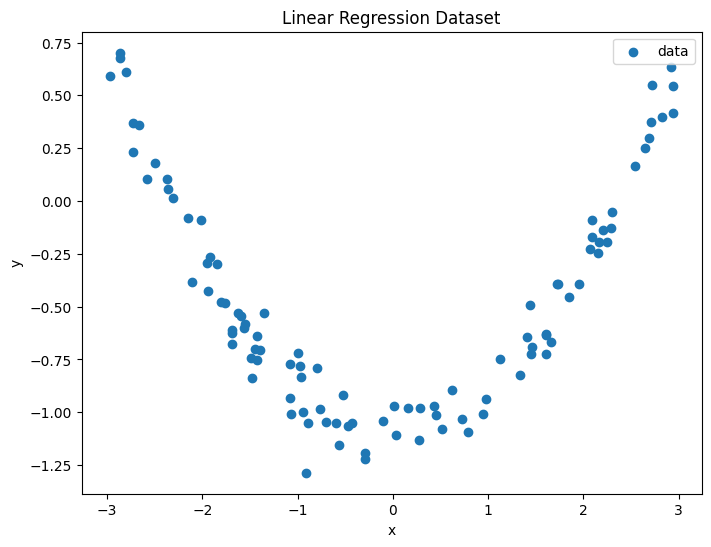

In [45]:
# prepare dataset
# linear regression: y = 2x + 1 + noise
x = numpy.random.rand(100, 1) * 6 - 3

# y = 2 * x + 1 + numpy.random.randn(100, 1)
y = (2 * x**2 -1 + numpy.random.randn(100, 1)) / 10 - 1


# plot 
plt.figure(figsize=(8, 6))
plt.scatter(x, y, label='data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Dataset')
plt.legend()
plt.show()

In [46]:
# define model
class Model(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.f1 = torch.nn.Linear(1, 3)  # input_dim=1, output_dim=3
        self.f2 = torch.nn.Linear(3, 3)
        self.f3 = torch.nn.Linear(3, 1)  # input_dim=3, output_dim=1

    def forward(self, x):
        # return self.linear(x)
        out = self.f1(x)  # (1,3)　行列かける
        out = torch.relu(out)  # 非線形な関数を通す
        out = self.f2(out) # (3,3)　行列かける
        out = torch.relu(out) # 非線形な関数を通す
        out = self.f3(out)  # (3,1)　行列かける
        return out

In [51]:
# define training loop
def train(model, x_train, y_train, num_epochs=1000, learning_rate=0.01):
    criterion = torch.nn.MSELoss()
    # optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # plot 
    plt.figure(figsize=(8, 6))
    plt.scatter(x_train.numpy(), y_train.numpy(), label='data')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Linear Regression Training')

    cmap = plt.get_cmap('viridis')

    for epoch in range(num_epochs):
        # training前の準備：モデルを訓練モードに設定し、勾配を初期化する
        model.train()
        optimizer.zero_grad()
        # training 開始
        outputs = model(x_train) # y_pred = f(x_train) 
        # loss = criterion(outputs, y_train)  # chi-equare: loss = (y_pred - y_train)^2
        # 自前実装
        loss = torch.mean((outputs - y_train) ** 2)
        loss.backward()  # 勾配計算
        optimizer.step()

        # num_epochsの10%ごとに学習の進捗を表示
        if (epoch + 1) % (num_epochs // 10) == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

            # plot regression line
            with torch.no_grad():
                predicted = model(x_train).detach().numpy()
            # plot用にデータをソート
            sorted_indices = x_train.numpy().argsort(axis=0).flatten()
            plt.plot(x_train.numpy()[sorted_indices], predicted[sorted_indices], label=f'Epoch {epoch+1}', color=cmap(epoch / num_epochs))

    plt.legend()
    plt.show()



Epoch [1000/10000], Loss: 0.2774
Epoch [2000/10000], Loss: 0.0468
Epoch [3000/10000], Loss: 0.0152
Epoch [4000/10000], Loss: 0.0129
Epoch [5000/10000], Loss: 0.0127
Epoch [6000/10000], Loss: 0.0127
Epoch [7000/10000], Loss: 0.0127
Epoch [8000/10000], Loss: 0.0127
Epoch [9000/10000], Loss: 0.0127
Epoch [10000/10000], Loss: 0.0127


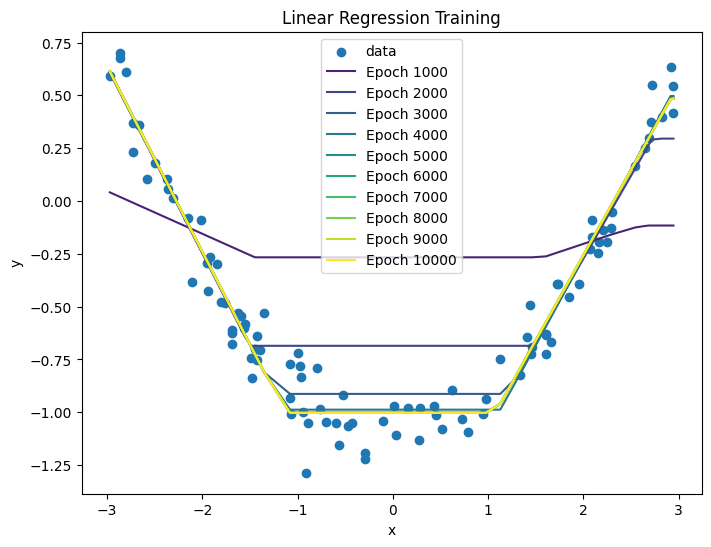

In [52]:
# training start
model = Model()
x_train = torch.from_numpy(x).float()
y_train = torch.from_numpy(y).float()
train(model, x_train, y_train, num_epochs=10000, learning_rate=0.001)